# Day 43: Word Embedding & Positional Encoding


## My Style Enhanced Notebook

This notebook follows the structure:

Theory → Intuition → Mathematics → Worked Examples →
Hands-On → Mini Project → Interview Prep.

Business Analogy:
Embedding = Employee profile
Position = Seat number in a board meeting
Same employees + different seats = different interactions.


# Learning Objectives


- Understand embeddings deeply
- Learn how embeddings are trained
- Study Word2Vec, CBOW, Skip-Gram
- Understand Transformer input pipeline
- Master sinusoidal positional encoding
- Compare sentence order effects


# Word Embeddings


Embeddings are trainable dense vectors.

Why not one-hot?
- Sparse
- Huge dimensionality
- No semantic similarity

Embeddings:
- Dense
- Compact
- Meaningful


# How Embedding Weights Are Learned


1. Random initialization
2. Forward pass
3. Loss computation
4. Backpropagation
5. Gradient updates
6. Semantic structures emerge


# Word2Vec Intuition


Skip-Gram:
Center word predicts context.

CBOW:
Context predicts center word.

LLMs:
Previous tokens predict next token.


# Positional Encoding


Self-attention is permutation invariant.

Need order information.

Original Transformer uses sinusoidal encoding.

Modern models:
- BERT: Learned PE
- GPT-2: Learned PE
- LLaMA: RoPE


# John Likes Burger Example


John likes Burger
Burger likes John

Same vocabulary.
Different meaning.

Embedding + Position → Different final vectors.


# Interview Questions


1. Why embeddings?
2. How are they trained?
3. Why positional encoding?
4. Why sine/cosine?
5. Learned vs fixed encoding?
6. RoPE advantages?


In [1]:
import numpy as np

embeddings={
    "John":np.array([0.2,0.8,0.1,0.5]),
    "likes":np.array([0.6,0.3,0.9,0.2]),
    "Burger":np.array([0.7,0.1,0.4,0.8])
}

embeddings


{'John': array([0.2, 0.8, 0.1, 0.5]),
 'likes': array([0.6, 0.3, 0.9, 0.2]),
 'Burger': array([0.7, 0.1, 0.4, 0.8])}

# Hands-On 1


Embedding lookup for two sentences.
Observe how order changes matrices.


In [2]:
s1=["John","likes","Burger"]
s2=["Burger","likes","John"]

m1=np.array([embeddings[w] for w in s1])
m2=np.array([embeddings[w] for w in s2])

print(m1)
print()
print(m2)


[[0.2 0.8 0.1 0.5]
 [0.6 0.3 0.9 0.2]
 [0.7 0.1 0.4 0.8]]

[[0.7 0.1 0.4 0.8]
 [0.6 0.3 0.9 0.2]
 [0.2 0.8 0.1 0.5]]


# Hands-On 2


Add positional vectors manually.


In [3]:
positions=np.array([
[0,1,0,1],
[0.84,0.54,0.01,0.999],
[0.91,-0.42,0.02,0.999]
])

f1=m1+positions
f2=m2+positions

print(f1)
print()
print(f2)


[[ 0.2    1.8    0.1    1.5  ]
 [ 1.44   0.84   0.91   1.199]
 [ 1.61  -0.32   0.42   1.799]]

[[0.7   1.1   0.4   1.8  ]
 [1.44  0.84  0.91  1.199]
 [1.11  0.38  0.12  1.499]]


# Hands-On 3


Generate sinusoidal positional encoding from scratch.


In [4]:
def positional_encoding(seq_len,d_model):
    pe=np.zeros((seq_len,d_model))
    for pos in range(seq_len):
        for i in range(0,d_model,2):
            pe[pos,i]=np.sin(pos/(10000**(i/d_model)))
            if i+1<d_model:
                pe[pos,i+1]=np.cos(pos/(10000**(i/d_model)))
    return pe

pe=positional_encoding(10,8)
print(pe)


[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 8.41470985e-01  5.40302306e-01  9.98334166e-02  9.95004165e-01
   9.99983333e-03  9.99950000e-01  9.99999833e-04  9.99999500e-01]
 [ 9.09297427e-01 -4.16146837e-01  1.98669331e-01  9.80066578e-01
   1.99986667e-02  9.99800007e-01  1.99999867e-03  9.99998000e-01]
 [ 1.41120008e-01 -9.89992497e-01  2.95520207e-01  9.55336489e-01
   2.99955002e-02  9.99550034e-01  2.99999550e-03  9.99995500e-01]
 [-7.56802495e-01 -6.53643621e-01  3.89418342e-01  9.21060994e-01
   3.99893342e-02  9.99200107e-01  3.99998933e-03  9.99992000e-01]
 [-9.58924275e-01  2.83662185e-01  4.79425539e-01  8.77582562e-01
   4.99791693e-02  9.98750260e-01  4.99997917e-03  9.99987500e-01]
 [-2.79415498e-01  9.60170287e-01  5.64642473e-01  8.25335615e-01
   5.99640065e-02  9.98200540e-01  5.99996400e-03  9.99982000e-01]
 [ 6.56986599e-01  7.53902254e-01  6.44217687e-01  7.64842187e-01
   

# Hands-On 4


Visualize sinusoidal curves.


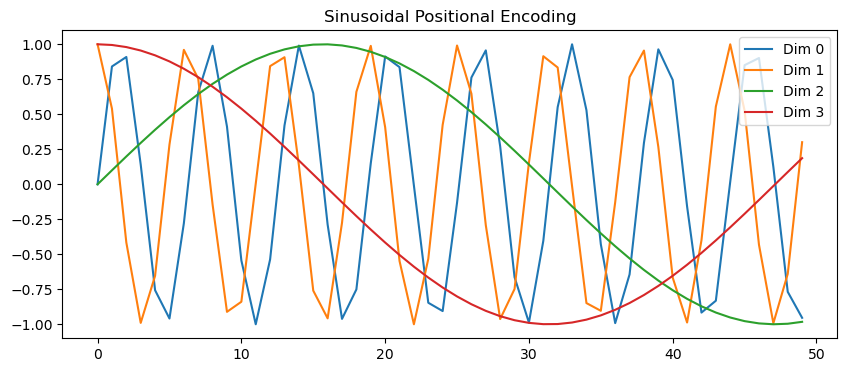

In [5]:
import matplotlib.pyplot as plt

pe=positional_encoding(50,8)

plt.figure(figsize=(10,4))
for i in range(4):
    plt.plot(pe[:,i], label=f"Dim {i}")

plt.legend()
plt.title("Sinusoidal Positional Encoding")
plt.show()


# Hands-On 5


Build mini Transformer input pipeline.


In [6]:
sentence="John likes Burger".split()

vocab={w:i for i,w in enumerate(set(sentence))}
ids=[vocab[w] for w in sentence]

print("Vocabulary:",vocab)
print("Token IDs:",ids)

emb=np.random.randn(len(vocab),4)

inputs=np.array([emb[i] for i in ids])

pe=positional_encoding(len(sentence),4)

final=inputs+pe

print("\nFinal Transformer Inputs")
print(final)


Vocabulary: {'Burger': 0, 'John': 1, 'likes': 2}
Token IDs: [1, 2, 0]

Final Transformer Inputs
[[-1.0353777  -0.49219661 -0.22405888  1.15046756]
 [ 1.90231289  0.48324239  0.85892956  1.09975434]
 [ 0.97904813 -0.54530029  0.547392    2.78769083]]


# BFSI Analogy


Fraud detection:
Transaction embeddings represent meaning.
Sequence positions represent event order.

Same events in different order may indicate fraud.


# Summary


Word Embedding = What?
Positional Encoding = Where?
Attention = Who interacts with whom?
Transformer = Understands context using all three.
